In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

import warnings


In [2]:
df = pd.read_csv('data/data.csv')

df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Predict the `math_score` keeping the rest as the independent feature and `math_score` as dependent feature

In [3]:
X = df.drop('math_score', axis=1)
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [4]:
y = df['math_score']
y.head()

0    72
1    69
2    90
3    47
4    76
Name: math_score, dtype: int64

#### Create Preprocessing transformer pipeline


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

catogarical_feature = X.select_dtypes(include='object').columns
numerical_feature = X.select_dtypes(exclude='object').columns

oh_transformer = OneHotEncoder()
std_transformer = StandardScaler() 

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, catogarical_feature),
        ("StandardScaler", std_transformer, numerical_feature) 
    ]
)


In [6]:
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [7]:
type(X)

pandas.core.frame.DataFrame

In [8]:
X = preprocessor.fit_transform(X)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

X_train.shape, X_test.shape

((750, 19), (250, 19))

#### Creat evaluation function

In [10]:
def evaluate_model(true, predicted):
    mse = mean_squared_error(true, predicted)
    mae = mean_absolute_error(true, predicted)
    r_square = r2_score(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    return mse, mae, r_square, rmse

In [11]:
models = {
    "Linear Regression": LinearRegression(),
    "AdaBoostRegressor": AdaBoostRegressor(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "K Nearest Neighbors": KNeighborsRegressor(),
    "XG Boost": XGBRegressor(),
    "Decistion Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Support Vector Machine": SVR()
}

model_list = []
r2_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]

    model.fit(X_train, y_train)

    # Make prediction
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate model on Train and test dataset
    model_train_mse, model_train_mae, model_train_r_square, model_train_rmse = evaluate_model(y_train, y_train_pred)
    model_test_mse, model_test_mae, model_test_r_square, model_test_rmse = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print("Model Performance for training set:")
    print(f"- Mean Squared Error (MSE): {model_train_mse}")
    print(f"- Mean Absolute Error (MAE): {model_train_mae}")
    print(f"- R Squared): {model_train_r_square}")
    print(f"- Root Mean Squared Error (RMSE): {model_train_rmse}")

    print("------------------------------------------------------")

    print("Model Performance for testing set:")
    print(f"- Mean Squared Error (MSE): {model_test_mse}")
    print(f"- Mean Absolute Error (MAE): {model_test_mae}")
    print(f"- R Squared): {model_test_r_square}")
    print(f"- Root Mean Squared Error (RMSE): {model_test_rmse}")
    r2_list.append(model_test_r_square)

    print("=" * 70)

Linear Regression
Model Performance for training set:
- Mean Squared Error (MSE): 26.484347624819915
- Mean Absolute Error (MAE): 4.106415697610671
- R Squared): 0.8829150397302321
- Root Mean Squared Error (RMSE): 5.146294552862274
------------------------------------------------------
Model Performance for testing set:
- Mean Squared Error (MSE): 34.35131539383603
- Mean Absolute Error (MAE): 4.681931064971478
- R Squared): 0.856571033952073
- Root Mean Squared Error (RMSE): 5.860999521739959
AdaBoostRegressor
Model Performance for training set:
- Mean Squared Error (MSE): 33.22696806469903
- Mean Absolute Error (MAE): 4.6875601907535795
- R Squared): 0.8531065106510591
- Root Mean Squared Error (RMSE): 5.7642838292973595
------------------------------------------------------
Model Performance for testing set:
- Mean Squared Error (MSE): 49.389646585621946
- Mean Absolute Error (MAE): 5.5443082603044935
- R Squared): 0.7937806496772636
- Root Mean Squared Error (RMSE): 7.027776788261

In [15]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model', "R2_Score",]).sort_values(by=['R2_Score'], ascending=False)

,Model,R2_Score
0,Linear Regression,0.856571
2,Ridge,0.856458
5,XG Boost,0.818734
7,Random Forest,0.811798
1,AdaBoostRegressor,0.793781
4,K Nearest Neighbors,0.780148
3,Lasso,0.775806
8,Support Vector Machine,0.727657
6,Decistion Tree,0.676176


#### Model Training

In [19]:
type(y_test)

pandas.core.series.Series

In [20]:
model= LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

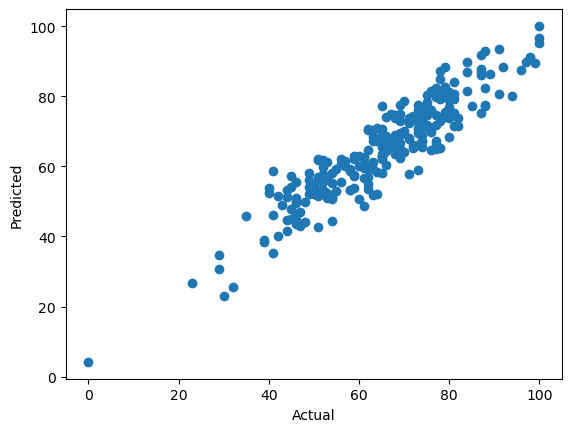

In [23]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

<Axes: xlabel='math_score'>

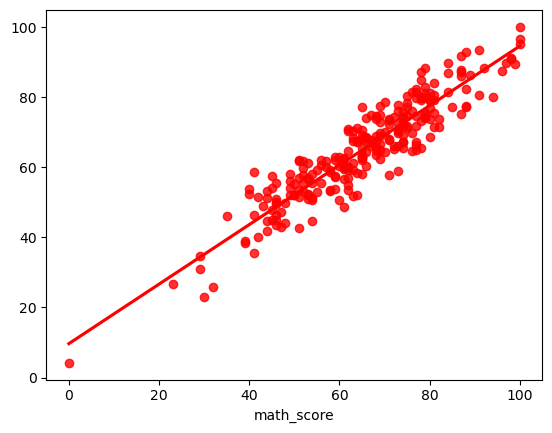

In [26]:
sns.regplot(x = y_test, y = y_pred, color='red', ci=None)